Trajectory max vel_mag: 4.086945000082703 and max acc_mag: 2.689072295551758


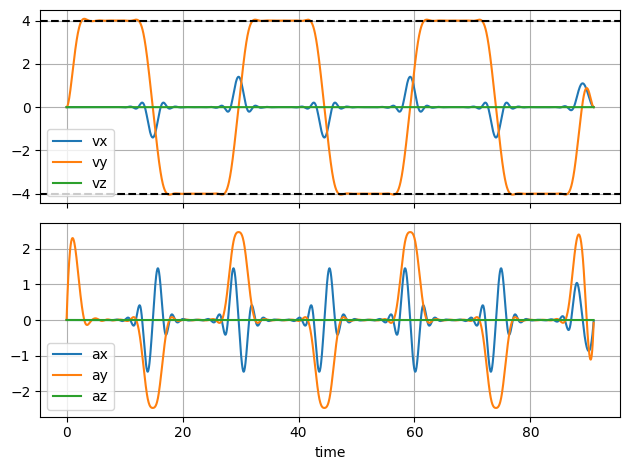

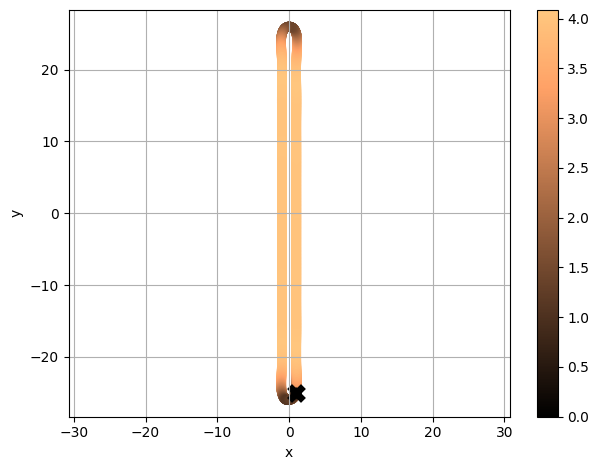

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

df = pd.read_csv(
    "/home/morten/workspaces/noetic_ws/src/large_scale_traj_optimizer/min_snap_traj_gen/trajectory.csv"
)

vmax = 4.0

fig, ax = plt.subplots(nrows=2, sharex=True)
df.plot(ax=ax[0], x="time", y=["vx", "vy", "vz"])
ax[0].axhline(-vmax, color='k', ls='--')
ax[0].axhline(vmax, color='k', ls='--')
ax[0].grid()
df.plot(ax=ax[1], x="time", y=["ax", "ay", "az"])
ax[1].grid()
fig.tight_layout()

vel_mag = np.linalg.norm(df[["vx", "vy", "vz"]], axis=1)
acc_mag = np.linalg.norm(df[['ax','ay','az']], axis=1)

print(f"Trajectory max vel_mag: {np.max(vel_mag)} and max acc_mag: {np.max(acc_mag)}")

fig, ax = plt.subplots()
sc = ax.scatter(df["px"], df["py"], c=vel_mag, cmap='copper')
ax.scatter([df["px"].iloc[0]], [df["py"].iloc[0]], s=100, c="k", marker="x", lw=5)
ax.grid()
ax.axis("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(sc)
fig.tight_layout()